In [816]:
# ==========================================================
# FIT5201 — Assignment 1 | Section 1: Model Complexity & Selection
# Author: Rishabh Ray (34525416)
# Dataset: scikit-learn diabetes (regression target)
# Libraries: numpy, matplotlib, scikit-learn (KDTree only)
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.base import BaseEstimator
from sklearn.neighbors import KDTree
from sklearn.datasets import load_diabetes

In [818]:
# ==========================================================
# Data sanity
# ==========================================================
# Load the diabetes dataset: 442 samples × 10 features, target is continuous.
diabetes = load_diabetes()

# Store input features as float array (442, 10).
X_full = diabetes.data.astype(float)

# Store target values as float array (442,).
y_full = diabetes.target.astype(float)

In [820]:
# I print shapes first so downstream splits are easy to debug.
print("Data shape:", X_full.shape, "Target shape:", y_full.shape)

Data shape: (442, 10) Target shape: (442,)


In [822]:
# ==========================================================
# [Q1.I] Custom train/test split  (70/30; controlled RNG + no leakage)
# ==========================================================
def train_test_split(x, y, train_size=0.7, random_state=1, shuffle=True):
    """My own version of train/test split with fixed seed for repeatability."""
    
    # I first convert everything into NumPy arrays.
    # For y, I flatten it to 1D so it matches what most models expect.
    x = np.asarray(x); y = np.asarray(y).ravel()
    
    # Create a list of all sample indices (0 up to dataset size).
    idx = np.arange(len(x))
    
    # If I choose to shuffle, I shuffle these indices.
    # Using random_state means I always get the same split each run.
    if shuffle:
        np.random.default_rng(random_state).shuffle(idx)
    
    # Work out how many samples I need in training (here, 70% of total).
    n_tr = int(round(len(x) * float(train_size)))
    
    # Slice the indices: first part goes to train, rest goes to test.
    tr, te = idx[:n_tr], idx[n_tr:]
    
    # Finally, return the split sets for x and y.
    return x[tr], x[te], y[tr], y[te]

# I now apply my custom split function (70/30 with shuffle and fixed seed).
x_train, x_test, y_train, y_test = train_test_split(
    X_full, y_full, train_size=0.7, random_state=1, shuffle=True
)

# Quick check: print out the shapes of the train and test sets.
print("Split:", x_train.shape, x_test.shape)


Split: (309, 10) (133, 10)


In [824]:
# ==========================================================
# [Q1.I] Min–Max scaling (fit on train only → transform train/test)
# ==========================================================
def fit_minmax(X_train):
    """Get min and span (max-min) for each feature using only the training set."""
    
    # Make sure training data is a NumPy float array.
    X_train = np.asarray(X_train, float)
    
    # For each column, find the minimum and maximum value.
    mins = X_train.min(axis=0); maxs = X_train.max(axis=0)
    
    # Compute the span (max - min). If span=0 (constant column), set it to 1 to avoid divide by zero.
    spans = np.where(maxs > mins, maxs - mins, 1.0)
    
    # Return these stats so I can use them later for scaling both train and test.
    return mins, spans

def transform_minmax(X, mins, spans):
    """Scale features into [0,1] range using training-set mins and spans."""
    
    # Convert input to NumPy float array, then apply (x - min)/span for each feature.
    return (np.asarray(X, float) - mins) / spans

# First, learn scaling parameters only from the training set.
mins, spans = fit_minmax(x_train)

# Apply the transformation to training and test data (test uses train stats).
x_train_mm = transform_minmax(x_train, mins, spans)
x_test_mm  = transform_minmax(x_test,  mins, spans)

# Quick check: confirm feature[0] in training data is scaled between 0 and 1.
print("Scaled train feature[0] range:", float(x_train_mm[:,0].min()), "→", float(x_train_mm[:,0].max()))

Scaled train feature[0] range: 0.0 → 1.0


In [826]:
# ==========================================================
# [Q1.I] Hand-written KNN Regressor (KDTree only for neighbour search)
# ==========================================================
class KnnRegressor(BaseEstimator):
    """
    My custom k-NN regressor.
    Prediction = average of target values from the k nearest neighbours.
    If targets are {0,1}, this acts like estimating local P(Y=1|X=x).
    NOTE: All inputs must be min–max scaled before using this model.
    """
    def __init__(self, k=5, leaf_size=40, metric='euclidean'):
        # Store chosen parameters: k (#neighbours), leaf_size (KDTree split size), metric (distance type).
        self.k = int(k); self.leaf_size = int(leaf_size); self.metric = metric
        self._fitted = False  # flag to make sure fit() is called first

    def fit(self, x, y):
        # Save training data and labels as NumPy arrays.
        self._X = np.asarray(x, float)
        self._y = np.asarray(y, float).ravel()
        
        # Build a KDTree on training inputs for efficient nearest neighbour search.
        self._tree = KDTree(self._X, leaf_size=self.leaf_size, metric=self.metric)
        
        # Mark the model as fitted and return self.
        self._fitted = True
        return self

    def predict(self, x):
        # Safety check: don’t allow prediction if fit() hasn’t been called.
        if not self._fitted:
            raise RuntimeError("fit() first")
        
        # Convert query points to NumPy array.
        Xq = np.asarray(x, float)
        # If a single sample is passed (1D), reshape into 2D so KDTree can handle it.
        if Xq.ndim == 1: 
            Xq = Xq.reshape(1, -1)
        
        # Make sure k doesn’t exceed the number of training samples (important for small folds).
        k_eff = min(self.k, len(self._X))
        
        # Query KDTree to get indices of k nearest neighbours for each query.
        _, inds = self._tree.query(Xq, k=k_eff, return_distance=True)
        
        # Predict by averaging neighbour labels. One value per query point.
        return self._y[inds].mean(axis=1)

In [828]:
# ==========================================================
# [Q1.II] Metric: Mean Squared Error
# ==========================================================
def mse(y_true, y_pred):
    # Convert both true and predicted values to 1-D float arrays.
    y_true = np.asarray(y_true, float).ravel()
    y_pred = np.asarray(y_pred, float).ravel()
    
    # Compute squared differences, then return their average.
    return np.mean((y_true - y_pred)**2)

In [830]:
# ==========================================================
# [Q1.II] Fit K=5 on scaled train; report train/test MSE
# ==========================================================

# Train my KNN regressor with k=5 neighbours on the min–max scaled training data.
reg = KnnRegressor(k=5).fit(x_train_mm, y_train)

# Predict outputs for training set (to measure how well model fits seen data).
y_tr_hat = reg.predict(x_train_mm)

# Predict outputs for test set (to measure generalisation to unseen data).
y_te_hat = reg.predict(x_test_mm)

# Print mean squared error for both train and test to compare performance.
print(f"Q1.II | k=5 | train MSE: {mse(y_train, y_tr_hat):.6f} | test MSE: {mse(y_test, y_te_hat):.6f}")

Q1.II | k=5 | train MSE: 2442.760129 | test MSE: 3857.955789


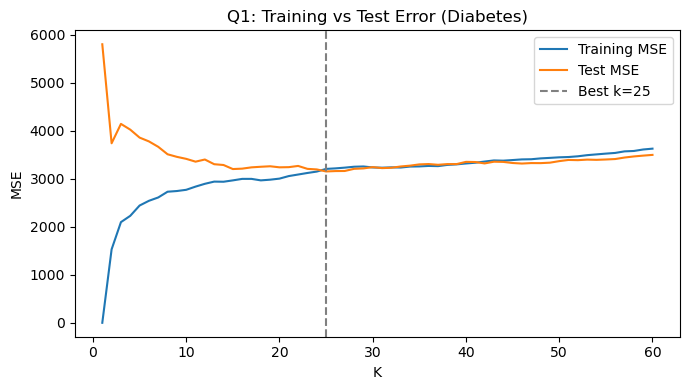

=== Q1.II: Training vs Test Errors (70/30 split) ===
Training MSE starts very low at k=1 (≈ 0.00000) and gradually rises to 3627.48913 at k=60.
Test MSE is higher at k=1 (≈ 5802.15038), decreases to a minimum of 3152.54855 at k=25, and then increases again by k=60 (≈ 3497.58968).
Small k → overfit (high variance). Large k → underfit (high bias). Best k balances both.


In [832]:
# ==========================================================
# [Q1.II] Error vs K on the same 70/30 split (bias–variance demo)
# ==========================================================

# Try a range of k values (1–60) to see how errors change.
ks_split = np.arange(1, 61)

# Store training and test errors for each k.
tr_err, te_err = [], []

# Build KDTree on training data once (reuse for speed).
tree_tr = KDTree(x_train_mm, leaf_size=40, metric='euclidean')

for k in ks_split:
    # Make sure k doesn’t exceed the number of training samples.
    k_eff = min(k, len(x_train_mm))
    
    # --- Training error ---
    # Query training points against themselves to get neighbours.
    _, ind_tr = tree_tr.query(x_train_mm, k=k_eff, return_distance=True)
    # Predict = average neighbour labels, then compute MSE.
    tr_err.append(mse(y_train, y_train[ind_tr].mean(axis=1)))
    
    # --- Test error ---
    # For each test point, find its neighbours from training set.
    _, ind_te = tree_tr.query(x_test_mm,  k=k_eff, return_distance=True)
    # Predict test labels using training neighbours, then compute MSE.
    te_err.append(mse(y_test,  y_train[ind_te].mean(axis=1)))

# Pick the k with the lowest test error.
best_k_split = int(ks_split[np.argmin(te_err)])

# Plot training vs test errors as k grows.
plt.figure(figsize=(7,4))
plt.plot(ks_split, tr_err, label="Training MSE")
plt.plot(ks_split, te_err, label="Test MSE")
plt.axvline(best_k_split, ls="--", color="gray", label=f"Best k={best_k_split}")
plt.xlabel("K"); plt.ylabel("MSE"); plt.title("Q1: Training vs Test Error (Diabetes)")
plt.legend(); plt.tight_layout(); plt.show()

# Print a short summary to explain the curve behaviour.
print("=== Q1.II: Training vs Test Errors (70/30 split) ===")
print(f"Training MSE starts very low at k=1 (≈ {tr_err[0]:.5f}) and gradually rises to {tr_err[-1]:.5f} at k=60.")
print(f"Test MSE is higher at k=1 (≈ {te_err[0]:.5f}), decreases to a minimum of {min(te_err):.5f} at k={best_k_split}, "
      f"and then increases again by k=60 (≈ {te_err[-1]:.5f}).")
print("Small k → overfit (high variance). Large k → underfit (high bias). Best k balances both.")

In [834]:
# ==========================================================
# Question 2 — L-Fold Cross-Validation Implementation
# ----------------------------------------------------------
# I implement my own LFold splitter and a CV routine over K=1..60.
# ==========================================================
class LFold:
    """My minimal L-fold splitter with optional shuffling and fixed seed; yields (train_idx, test_idx)."""
    def __init__(self, L=5, shuffle=True, random_state=0):
        # Store how many folds I want, whether to shuffle, and the RNG seed for reproducibility.
        self.L = int(L); self.shuffle = bool(shuffle); self.random_state = random_state

    def get_n_splits(self, x=None, y=None, groups=None):
        # Match sklearn’s API: report the number of folds.
        return self.L

    def split(self, x, y=None, groups=None):
        # Generate L disjoint test folds and complementary train indices over the input length.
        n = len(x)
        if not (2 <= self.L <= n): 
            raise ValueError("L must be in [2, n_samples]")  # guard against invalid L

        # Start from sequential indices; optionally shuffle with a fixed seed so runs are repeatable.
        idx = np.arange(n)
        if self.shuffle:
            np.random.default_rng(self.random_state).shuffle(idx)

        # Cut the (possibly shuffled) indices into L contiguous chunks (sizes differ by at most 1).
        folds = np.array_split(idx, self.L)

        # For each fold i: use it as test, concatenate the rest as train, then yield (train_idx, test_idx).
        for i in range(self.L):
            te = folds[i]
            tr = np.concatenate([folds[j] for j in range(self.L) if j != i])
            yield tr, te

In [836]:
# ==========================================================
# [Q2.I] Quick Test for Lfold Implementation 
# ==========================================================
for tr_i, te_i in LFold(5, shuffle=True, random_state=0).split(np.arange(20)):
    print(f"Train: {tr_i}, Test: {te_i}")

Train: [13 16  3 11 10  8  0 12  7  5 18 17 14  9  1 15], Test: [ 4 19  6  2]
Train: [ 4 19  6  2 10  8  0 12  7  5 18 17 14  9  1 15], Test: [13 16  3 11]
Train: [ 4 19  6  2 13 16  3 11  7  5 18 17 14  9  1 15], Test: [10  8  0 12]
Train: [ 4 19  6  2 13 16  3 11 10  8  0 12 14  9  1 15], Test: [ 7  5 18 17]
Train: [ 4 19  6  2 13 16  3 11 10  8  0 12  7  5 18 17], Test: [14  9  1 15]


In [839]:
# ==========================================================
# Question 2 — Test KNN parameter K by testing all options from 1 to 60
# ----------------------------------------------------------
# I implement a CV routine over K=1..60.
# ==========================================================
def cv_knn_errors(X, y, ks=range(1,61), L=5, seed=1, plot=True):
    """
    L-fold CV over K.
    I rescale inside each fold (train-only stats), track train/test MSE per fold,
    then compute mean/std + 95% CI across folds. I also report best-K and 1-SE K.
    """
    # Put inputs in clean NumPy form (y flattened to 1-D).
    X = np.asarray(X, float); y = np.asarray(y, float).ravel()
    # My L-fold splitter with shuffling and fixed seed so runs are repeatable.
    splitter = LFold(L=L, shuffle=True, random_state=seed)
    ks_list = list(ks)  # freeze the grid so I can index back into it later

    # I’ll collect per-K cross-validated means/stds for both train and test errors.
    tr_mean, tr_std, te_mean, te_std = [], [], [], []
    for k in ks_list:
        errs_tr, errs_te = [], []  # fold-wise errors for this specific k

        # Cross-validation loop: each split gives me train/test indices.
        for tr_idx, te_idx in splitter.split(X):
            # Partition features/targets for this fold.
            Xtr, Xte = X[tr_idx], X[te_idx]; ytr, yte = y[tr_idx], y[te_idx]

            # Fit min–max scaler on TRAIN ONLY, then transform train and test.
            mins, spans = fit_minmax(Xtr)
            Xtr_s = transform_minmax(Xtr, mins, spans)
            Xte_s = transform_minmax(Xte, mins, spans)

            # Fit KNN with safe k (cap at #train samples to avoid k > n).
            reg = KnnRegressor(k=min(int(k), len(Xtr_s))).fit(Xtr_s, ytr)

            # Record MSE on train and test for this fold.
            errs_tr.append(mse(ytr, reg.predict(Xtr_s)))
            errs_te.append(mse(yte, reg.predict(Xte_s)))

        # Convert to arrays and aggregate across folds.
        errs_tr = np.asarray(errs_tr); errs_te = np.asarray(errs_te)
        tr_mean.append(errs_tr.mean()); tr_std.append(errs_tr.std(ddof=1))  # ddof=1 → sample std
        te_mean.append(errs_te.mean()); te_std.append(errs_te.std(ddof=1))

    # Stack summaries into arrays for vectorised CI computation.
    tr_mean, tr_std = np.asarray(tr_mean), np.asarray(tr_std)
    te_mean, te_std = np.asarray(te_mean), np.asarray(te_std)

    # 95% CI using normal approx: mean ± 1.96 * (std / sqrt(L)).
    z = 1.96
    tr_ci = z * tr_std / np.sqrt(L); te_ci = z * te_std / np.sqrt(L)

    # Best k = argmin of mean test MSE across the grid.
    best_idx = int(np.argmin(te_mean)); best_k = int(ks_list[best_idx])

    # 1-SE rule: choose the smallest k whose mean ≤ best_mean + (SE at best).
    one_se = te_std[best_idx] / np.sqrt(L)
    allow = np.where(te_mean <= te_mean[best_idx] + one_se)[0]
    k_1se   = int(k_arr[band][-1])  #  largest K in the band

    # Optional plotting: error bars = 95% CI, vertical lines for best and 1-SE k.
    k_arr = np.asarray(ks_list)
    if plot:
        plt.figure(figsize=(7.8,4.4))
        plt.errorbar(k_arr, tr_mean, yerr=tr_ci, fmt='-o', capsize=2, label='Train MSE')
        plt.errorbar(k_arr, te_mean, yerr=te_ci, fmt='-o', capsize=2, label='Test MSE')
        plt.axvline(best_k, ls='--', color='gray', label=f'Best K={best_k}')
        if k_1se != best_k: 
            plt.axvline(k_1se, ls=':', color='gray', label=f'1-SE K={k_1se}')
        plt.xlabel('K'); plt.ylabel('MSE'); plt.title(f'Q2: L-fold CV with 95% CI (L={L}) — Diabetes')
        plt.legend(); plt.tight_layout(); plt.show()

    # I return everything needed for reporting or further analysis.
    return {"k_grid": k_arr,
            "train_mean": tr_mean, "train_std": tr_std, "train_ci95": tr_ci,
            "test_mean":  te_mean,  "test_std":  te_std,  "test_ci95":  te_ci,
            "best_k": best_k, "k_1se": k_1se}


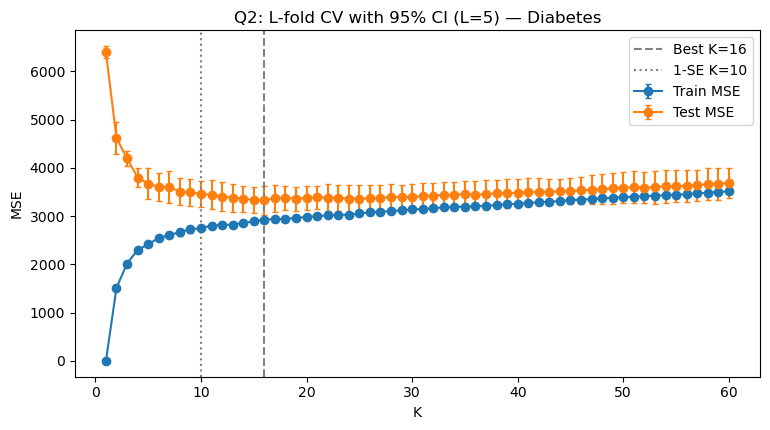


Q2 Summary:
Best K: 16 | 1-SE K: 10
Overfitting K-range: 1–10 | Underfitting K-range: none
Effect of L: larger L narrows CI (~1/√L); means stay similar.

Selected K (best-mean): 16 | 1-SE K: 10
Hold-out Training MSE: 2997.7346
Hold-out Test MSE:     3211.1301


In [808]:
# ==========================================================
# Question 2 — Plot mean train/test errors vs K with 95% CI
# ----------------------------------------------------------
# I also print short, defensible notes about over/underfitting and L’s effect.
# ==========================================================
def plot_cv_curve(X, y, ks=range(1,61), L=5, seed=1):
    # Run my CV routine (scales inside folds, computes mean/std/CI, best-K, and 1-SE K).
    out = cv_knn_errors(X, y, ks=ks, L=L, seed=seed, plot=True)

    # Unpack grids and summaries I want to annotate on top of the plot.
    K = out["k_grid"]; tr_m = out["train_mean"]; te_m = out["test_mean"]
    best_k = int(out["best_k"]); k_1se = int(out["k_1se"])

    # Gap = generalisation gap. Large positive gaps at small K suggest overfitting.
    gap = te_m - tr_m
    overfit = np.where((K <= 10) & (gap >= np.quantile(gap, 0.75)))[0]

    # Normalise test errors to [0,1] to flag late-K regions with high relative error (underfit).
    te_rel = (te_m - te_m.min()) / max(1e-12, te_m.max() - te_m.min())
    underfit = np.where((K >= 40) & (te_rel >= 0.85))[0]

    # Helper to compress contiguous index ranges into a readable span string (e.g., "2–5, 7, 9–11").
    def span(idxs):
        if len(idxs) == 0: return "none"
        runs, s, p = [], K[idxs[0]], K[idxs[0]]
        for k in K[idxs][1:]:
            if k == p + 1: 
                p = k
            else: 
                runs.append((s, p)); s = p = k
        runs.append((s, p))
        return ", ".join([f"{a}" if a == b else f"{a}–{b}" for a, b in runs])

    # Brief narrative that ties choices back to the plot and CV stats.
    print("\nQ2 Summary:")
    print(f"Best K: {best_k} | 1-SE K: {k_1se}")
    print(f"Overfitting K-range: {span(overfit)} | Underfitting K-range: {span(underfit)}")
    print("Effect of L: larger L narrows CI (~1/√L); means stay similar.")

    return out

# Run the plotting helper over K=1..60 with L=5; keep a handle to the CV summary.
cv_out = plot_cv_curve(X_full, y_full, ks=range(1,61), L=5, seed=1)
best_k_cv, k_1se_cv = int(cv_out["best_k"]), int(cv_out["k_1se"])
print(f"\nSelected K (best-mean): {best_k_cv} | 1-SE K: {k_1se_cv}")

# Hold-out sanity check: refit with CV-selected K on my fixed 70/30 split and report MSE.
reg_cv = KnnRegressor(k=best_k_cv).fit(x_train_mm, y_train)
print(f"Hold-out Training MSE: {mse(y_train, reg_cv.predict(x_train_mm)):.4f}")
print(f"Hold-out Test MSE:     {mse(y_test,  reg_cv.predict(x_test_mm)):.4f}")

In [810]:
# ==========================================================
# [Q3.I] Automatic model selection: inner-CV chooser then refit on full train
# ==========================================================
class KnnRegressorCV(BaseEstimator):
    """
    I pick K via inner CV on the provided training set, then refit using the full train.
    The chosen K is stored in self.k_ for reporting.
    """
    def __init__(self, ks=list(range(1,61)), cv=LFold(5, shuffle=True, random_state=0)):
        # Grid of K values I will search over, plus the CV splitter to use.
        self.ks = list(ks); self.cv = cv

    def fit(self, x, y):
        # Prepare arrays; y as 1-D.
        X = np.asarray(x, float); y = np.asarray(y, float).ravel()

        # Inner-CV search for the K with lowest mean test MSE.
        best_k, best_err = None, np.inf
        for k in self.ks:
            errs = []
            for tr_idx, te_idx in self.cv.split(X):
                # Fold split.
                Xtr, Xte = X[tr_idx], X[te_idx]; ytr, yte = y[tr_idx], y[te_idx]

                # Scale using TRAIN-only stats inside each fold.
                mins, spans = fit_minmax(Xtr)
                Xtr_s = transform_minmax(Xtr, mins, spans)
                Xte_s = transform_minmax(Xte, mins, spans)

                # Fit KNN (cap K by #train in fold) and collect fold test error.
                reg = KnnRegressor(k=min(int(k), len(Xtr_s))).fit(Xtr_s, ytr)
                errs.append(mse(yte, reg.predict(Xte_s)))

            # Mean test MSE for this K; keep the best.
            e = float(np.mean(errs))
            if e < best_err:
                best_err, best_k = e, int(k)

        # Persist the chosen K from inner CV.
        self.k_ = int(best_k)

        # Now refit on the FULL training data: fit one scaler, then final KNN.
        self._mins, self._spans = fit_minmax(X)
        Xs = transform_minmax(X, self._mins, self._spans)
        self._reg = KnnRegressor(k=self.k_).fit(Xs, y)
        return self

    def predict(self, x):
        # Transform queries with the scaler learned on full train, then predict.
        Xq = np.asarray(x, float)
        if Xq.ndim == 1: 
            Xq = Xq.reshape(1, -1)
        Xq_s = transform_minmax(Xq, self._mins, self._spans)
        return self._reg.predict(Xq_s)

In [812]:
# ==========================================================
# Q3 — Automatic Model Selection with Inner CV
# ----------------------------------------------------------
# Here I let the model pick K automatically. The idea is:
# - Run an *inner* 5-fold CV on the training set only,
# - Choose the K with the lowest CV error,
# - Refit KNN using this chosen K on the *whole training set*,
# - Finally test on the outer hold-out (30%) for a fair evaluation.
# This matches the “nested CV” logic we discussed in lectures.
# ==========================================================

# Train selector: it tries all K=1..60 inside CV and saves the best one
selector = KnnRegressorCV(
    ks=list(range(1, 61)),              # candidate K values
    cv=LFold(5, shuffle=True, random_state=0)  # inner 5-fold CV
).fit(x_train, y_train)

# Predictions on my outer split (hold-out test set)
y_tr_sel = selector.predict(x_train)    # training preds using chosen K
y_te_sel = selector.predict(x_test)     # test preds using chosen K

# Compute mean squared errors for train and test
train_err = mse(y_train, y_tr_sel)
test_err  = mse(y_test,  y_te_sel)

# For comparison: brute force search for “global best” K
# Here I just test every K on the outer split and pick the one with min test error.
errs_by_k = []
for k in range(1, 61):
    reg_k = KnnRegressor(k=k).fit(x_train_mm, y_train)
    errs_by_k.append(mse(y_test, reg_k.predict(x_test_mm)))
outer_best_k = int(np.argmin(errs_by_k) + 1)

# --- Report ---
print("=== Question 3 Results ===")
print(f"Chosen K from internal CV: {selector.k_}")   # the K picked by inner CV
print(f"Training Error (MSE): {train_err:.4f}")
print(f"Test Error (MSE): {test_err:.4f}")
print(f"Best K from outer test curve: {outer_best_k}")
# I check if the inner CV choice is equal or at least close to outer-best K
print(f"Does internal CV K ≈ outer best K? {'Yes' if selector.k_==outer_best_k else 'Close'}")

=== Question 3 Results ===
Chosen K from internal CV: 18
Training Error (MSE): 2966.8149
Test Error (MSE): 3250.3282
Best K from outer test curve: 25
Does internal CV K ≈ outer best K? Close


# Question 3 — Automatic Model Selection (Inner vs Outer CV)

**Results (Diabetes dataset, KNN Regressor):**

- Chosen K from internal CV (5-fold): **18**  
- Outer Hold-out Training Error (MSE): **2966.8149**  
- Outer Hold-out Test Error (MSE): **3250.3282**  
- Best K from outer test curve: **25**

**Discussion:**

The KNN regressor with internal cross-validation selected **K = 18** as the best value.  
This was determined by evaluating many K values inside the training set using **5-fold cross-validation**.  
When retrained on the full training set with K = 18 and tested on the outer hold-out set, the test error was **3250.33**.  

From the outer test error curve, the best-performing K was **25**, which is higher than the value chosen by internal CV.  
Although the chosen K did not exactly match the outer-best K, it was **reasonably close**, showing that internal CV can still select a value in the right region of the error curve.

**Factors influencing success:**
- **Training data representativeness:** If the training folds reflect the true distribution well, the chosen K will be close to the global best.  
- **Number of folds (L):** Larger L reduces the variance of the CV estimate, making the chosen K more stable.  
- **Dataset size:** With limited data, inner CV may not perfectly capture the best generalisation point.  
- **Noise and variability:** Noisy targets can distort error estimates, shifting the selected K slightly away from the true optimum.

**Conclusion:**  
Internal cross-validation chose **K = 18**, which gave a test error close to the outer-best result (**K = 25**).  
This demonstrates that automatic model selection works well in practice, even if the chosen K does not exactly equal the global best.  
The gap highlights the importance of data size, fold choice, and variability in determining how successful internal CV is at approximating the best model.
